In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import json 
import os 
from PIL import Image
from langchain_aws import ChatBedrock

In [2]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/hpTjb6liKBLVHQK0UgMi5A/Recipes.json
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/fQUs9wQ6aB6ts6fmkD2V2w/Synthetic-User-Reviews.json
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/5_Rr6ohviItzucyWk6nkrw/synthetic-recipe-images.zip

--2026-06-09 11:47:50--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/hpTjb6liKBLVHQK0UgMi5A/Recipes.json
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.45.118.108
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.45.118.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 66320 (65K) [application/json]
Saving to: ‘Recipes.json.1’

Recipes.json.1      100%[===================>]  64.77K  --.-KB/s    in 0.1s    

2026-06-09 11:47:51 (433 KB/s) - ‘Recipes.json.1’ saved [66320/66320]

--2026-06-09 11:47:51--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/fQUs9wQ6aB6ts6fmkD2V2w/Synthetic-User-Reviews.json
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.45.118.10

In [3]:
import zipfile

with zipfile.ZipFile("synthetic-recipe-images.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [4]:
### Your Code Here
### Step 1.1: Load the json file. Define the loaded data as recipe_data.
with open("Recipes.json","r") as f: 
    recipe_data = json.load(f)
### Step 1.2: Print each key-value pair of the first recipe. In this format: key (type of value): value
for key, value in recipe_data[0].items(): 
    print(f"Key:{key}, Value:{value}")
### Step 1.3: Show the image of the first recipe (recipe1)
img = Image.open("synthetic_recipe_images/recipe1.png")
img.show()

Key:id, Value:1
Key:name, Value:Classic Margherita Pizza
Key:cuisine, Value:Italian
Key:servings, Value:2
Key:prep_time, Value:20 mins
Key:cook_time, Value:15 mins
Key:total_time, Value:35 mins
Key:ingredients, Value:['1 pizza dough ball (about 260g)', '2 tablespoons tomato sauce', '1 cup shredded mozzarella cheese', '6-8 fresh basil leaves', '1 tablespoon olive oil', 'pinch of salt', 'optional: grated parmesan']
Key:directions, Value:['Preheat oven to 250°C (482°F) with a baking stone if available.', 'Roll out dough to a 12-inch circle on a floured surface.', 'Spread tomato sauce evenly over dough, leaving a 1/2-inch border.', 'Scatter mozzarella cheese over sauce.', 'Bake on the stone for 10-12 minutes until crust is crisp and cheese melts.', 'Finish with basil leaves, drizzle with olive oil, and season with salt and optional parmesan.', 'Slice and serve immediately.']


In [35]:
### Your Code Here: Fill in the blanks
import base64

def vision_llm(system_msg, prompt_txt, image_path):
    #system_msg: input system message for the LLM
    #prompt_txt: input user prompt for the LLM
    #image_path: the file path of the input image

    ### Credentials of the model
     
 
    ### Step 2.1: Define the model by ChatBedRock(Instead of ModelInference)
    model = ChatBedrock(
        model_id = "amazon.nova-lite-v1:0",
        region_name = "us-east-1"
    )

    ### Step 2.2: Encode the input image to a base64 string
    with open(image_path ,"rb") as f: 
        image_data = base64.b64encode(f.read()).decode("utf-8")

    ### Detect media type from file extension
    ext = os.path.splitext(image_path)[1].lower()
    media_type_map = {
        '.png':  'image/png',
        '.jpg':  'image/jpeg',
        '.jpeg': 'image/jpeg',
        '.gif':  'image/gif',
        '.webp': 'image/webp'
    }
    media_type = media_type_map.get(ext, 'image/jpeg')  # default to jpeg

    ### Step 2.3: Define the messages for the model
    
    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": [
            {
                "type": "image",       # ✅ "image" not "image_url"
                "source": {            # ✅ "source" not "image_url"
                    "type": "base64",
                    "media_type": f"{media_type}",  # ✅ e.g. "image/png"
                    "data": image_data
                }
            },
            {
                "type": "text",
                "text": prompt_txt
            }
        ]}
    ]

    ### Step 2.4: Get the response for the messages 
    response = model.invoke(messages)
    return response.content

In [36]:
### Your Code Here

### Define the food image caption prompts given a food name.
### The food name, as you have noticed, comes from the corresponding recipe data.
### You want to include the food name to ensure the model focuses on it while giving captions.
def image_caption_prompt_template(food_name):
    # food_name: the food name of the recipe

    ### Step 3.1: Design the prompts
    image_caption_system_msg = """You are a professional food photographer and a culinary expert.Your task is to generate concise,accurate
    and descriptive captions for food images.Focus only on what is visually present in the image.Do not speculate or add informations that isn't visible.
    Keep the caption to 2-3 sentences only."""
    image_caption_prompt_txt = f"""This is an image of {food_name}.
    Please describe the following visual details:
    - Visible ingredients and components
    - Cooking style and preparation method
    - Presentation and plating style
    - Portion size and serving style
    Keep your description factual and based only on what you can see in the image."""

    return image_caption_system_msg, image_caption_prompt_txt


### Test the prompts on the first recipe
### Step 3.2: Get the prompts with the food name of the first recipe
second_recipe = recipe_data[1] 
system_msg, prompt_txt = image_caption_prompt_template(recipe_data[2]['name'])

### Step 3.3: Get the test response and print it
response = vision_llm(
    system_msg = system_msg, 
    prompt_txt = prompt_txt, 
    image_path = f"""synthetic_recipe_images/recipe{recipe_data[2]["id"]}.png"""
)
print(response)

Tofu stir-fry with green beans, carrots, and broccoli served in a white bowl. A side of white rice in a small bowl. Wooden chopsticks beside the bowl.


In [37]:
### Your Code Here:

### Get captions for each image in the dataset and add to the JSON file (up tp 15 minutes)
### recipe_data is the recipe you loaded in Step 1
for i in range(len(recipe_data)):
    if (i+1)%20 == 0:
        print(f'{i+1} out of {len(recipe_data)} is done')

    ### Step 4.1: Get the caption prompts
    system_msg, prompt_txt = image_caption_prompt_template(recipe_data[i]["name"])
    ### Step 4.2: Get the response with the prompts
    response = vision_llm(
        system_msg = system_msg, 
        prompt_txt = prompt_txt, 
        image_path = f"""synthetic_recipe_images/recipe{recipe_data[i]["id"]}.png"""
    )

    ### Save the response as another item in the recipe data
    recipe_data[i]['image_description'] = response
print('ALL DONE!')


20 out of 109 is done
40 out of 109 is done
60 out of 109 is done
80 out of 109 is done
100 out of 109 is done
ALL DONE!


In [38]:
filename = 'augmented_food_recipe.json'
with open(filename, "w", encoding = "utf-8") as f: 
    json.dump(recipe_data, f, indent = 4)

In [19]:
### Part 1
### Your Code Here

### Step 1.1: Load the review dataset with variable name user_review_data
with open("Synthetic-User-Reviews.json" , "r") as f: 
     user_review_data = json.load(f)

### Step 1.2: Print the first review by key-value pairs
for key, values in user_review_data[0].items():
    print(f"Key :{key}, Value:{values}")


Key :reviewId, Value:900000001
Key :userId, Value:USER_FUSION_FINDER_99
Key :itemId, Value:1000001
Key :title, Value:A bit pricey, but that greenhouse vibe is so cozy
Key :text, Value:The Gilded Artichoke is definitely an upscale splurge. The lavender-rubbed chicken is unique, almost giving me tea-smoked vibes. It's a gorgeous, plant-filled escape from the city, though your wallet will feel it.
Key :date, Value:2025-11-15
Key :rating, Value:4.5
Key :language, Value:en
Key :images, Value:['https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/L0HyLOGuAlxwKZaCC8sJdg/Gemini-Generated-Image-523rkg523rkg523r.png','https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/YLCD9AYY985XxvP-K8CRbA/Gemini-Generated-Image-hy4y8why4y8why4y.png']


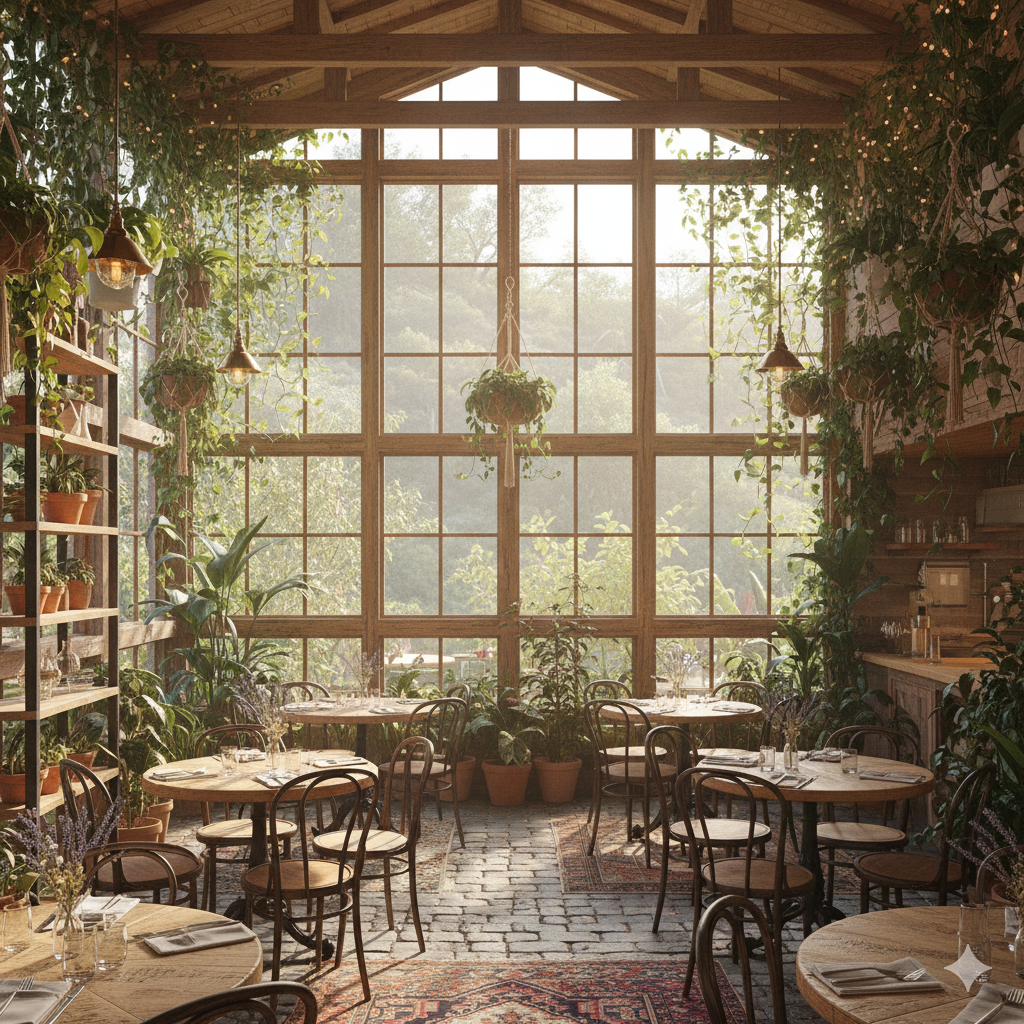

In [40]:
### Part 2
### Your Code Here

### Get the image by requesting from the URL
import ast # needed to convert string representation of list to actual python list
import requests

### Convert the list of images of the first user into the actual python list
### Step 1.3: Use ast.literal_eval to convert
images_list = ast.literal_eval(user_review_data[0]["images"])

### Step 1.4: Use the requests.get() method to get the FIRST image content
image_url = images_list[0]  # first image only
response = requests.get(image_url)

### Step 1.5: Write the image content to a temporary file 'review_image_placeholder.jpg'
with open('review_image_placeholder.png', 'wb') as f:
    f.write(response.content)

### Step 1.6: Open the 'review_image_placeholder.jpg' and show the image
img = Image.open('review_image_placeholder.png')
display(img)





In [41]:
### Prompt template: caption the images with the context of the reviews
def review_context_image_caption_prompt_template(reviews):
    # reviews: the written review content

    ### Step 2.1: Design your prompts
    review_context_image_caption_system_msg = """You are a culinary expert and food critic. 
    Your task is to generate concise and accurate image captions for food images.
    You will be provided with user reviews as context to guide your description.
    Align your caption with the sentiment and details expressed in the reviews.
    Focus only on what is visually present in the image.
    Keep the caption to 2-3 sentences."""

    review_context_image_caption_prompt_txt = f"""You are given the following user reviews about this dish:
    {reviews}
    
    Based on the image and the context provided by the reviews above:
    - Describe the visual appearance of the dish
    - Highlight elements that align with the sentiments in the reviews
    - Mention presentation, ingredients, and portion size if visible
    
    Keep your description factual, concise, and consistent with the reviews."""

    return review_context_image_caption_system_msg, review_context_image_caption_prompt_txt


### Step 2.2: Get the prompts
first_review = user_review_data[0]
reviews = first_review['text']  # the review text
system_msg, prompt_txt = review_context_image_caption_prompt_template(reviews)

### Step 2.3: Get the response by the vision_llm you defined previously
response = vision_llm(
    system_msg=system_msg,
    prompt_txt=prompt_txt,
    image_path='review_image_placeholder.png'  # the temp file we saved earlier
)
print(response)

A lush, plant-filled dining area features wooden tables and chairs, with tall windows showcasing a view of greenery outside. The setting evokes a serene, upscale atmosphere, consistent with the review's description of a "gorgeous, plant-filled escape."


In [42]:
from tenacity import retry, stop_after_attempt, wait_exponential

### URL Request function with Retry
@retry(stop=stop_after_attempt(10), wait=wait_exponential(multiplier=1, min=1, max=10))
def get_data_with_retry(url):
    response = requests.get(url, timeout=5)
    response.raise_for_status()  # Must raise error for retry to trigger
    return response

### Start the for loop
for i in range(len(user_review_data)):

    ### Step 3.1: Convert the string to the Python list of image urls
    review_images = ast.literal_eval(user_review_data[i]['images'])
    review_image_captions = []

    if len(review_images) > 0:
        for img_url in review_images:
            try:
                ### Step 3.2: Use get_data_with_retry to get the image_data
                image_data = get_data_with_retry(img_url)  
                print("Success!")
            except Exception as e:
                print(f"All retries failed at url {img_url}:", e)
                continue

            image = image_data.content
            with open('review_image_placeholder.png', 'wb') as img_file:
                img_file.write(image)

            ### Step 3.3: Get the prompts, get the response, append to review_image_captions
            system_msg, prompt_txt = review_context_image_caption_prompt_template(
                user_review_data[i]['text']
            )
            caption = vision_llm(
                system_msg=system_msg,
                prompt_txt=prompt_txt,
                image_path='review_image_placeholder.png'
            )
            review_image_captions.append(caption)

    ### Append the review_image_captions to the review data
    user_review_data[i]['image_captions'] = review_image_captions

    if (i+1) % 20 == 0:
        print(f'{i+1} out of {len(user_review_data)} done')

print('ALL DONE!')

Success!
Success!
Success!
Success!
Success!
Success!
Success!
Success!
Success!
ALL DONE!


In [43]:
filename = 'augmented_user_review.json'
with open(filename, 'w', encoding='utf-8') as f:
    json.dump(user_review_data, f, indent=4)